In [1]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris = load_iris()

In [3]:
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

In [4]:
data.head(2)

# rename
data.rename(columns={'sepal length (cm)': 'sepal_length',
                     'sepal width (cm)': 'sepal_width',
                     'petal length (cm)': 'petal_length',
                     'petal width (cm)': 'petal_width',
                     'target': 'species'}, inplace=True)


In [5]:
def class_match(x):
    if x == 0:
        return 'setosa'
    elif x == 1:
        return 'versicolor'
    else:
        return 'virginica'
    

data['species'] = data['species'].apply(class_match)


In [6]:
data.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


In [7]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


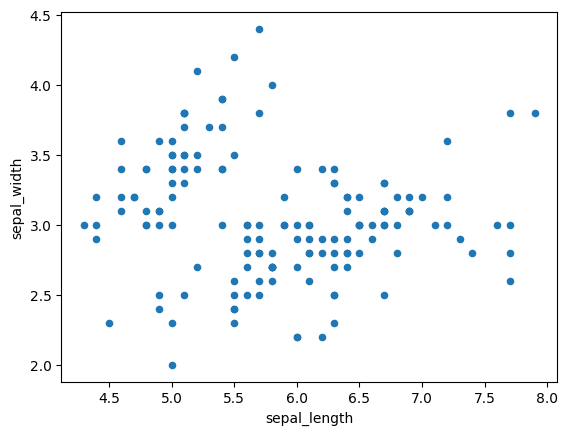

In [8]:
# 2D analysis
data.plot(kind='scatter', x='sepal_length', y='sepal_width')
plt.show()


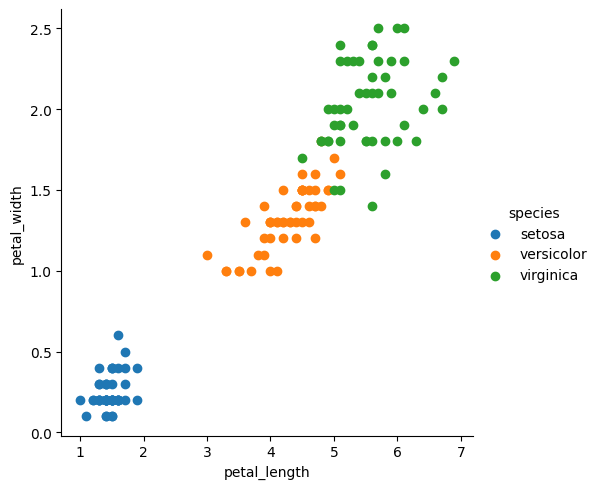

In [9]:
sns.FacetGrid(data, hue='species', height=5) \
.map(plt.scatter, 'petal_length', 'petal_width').add_legend()
plt.show()

In [10]:
# iris.keys()

In [11]:
# iris.target

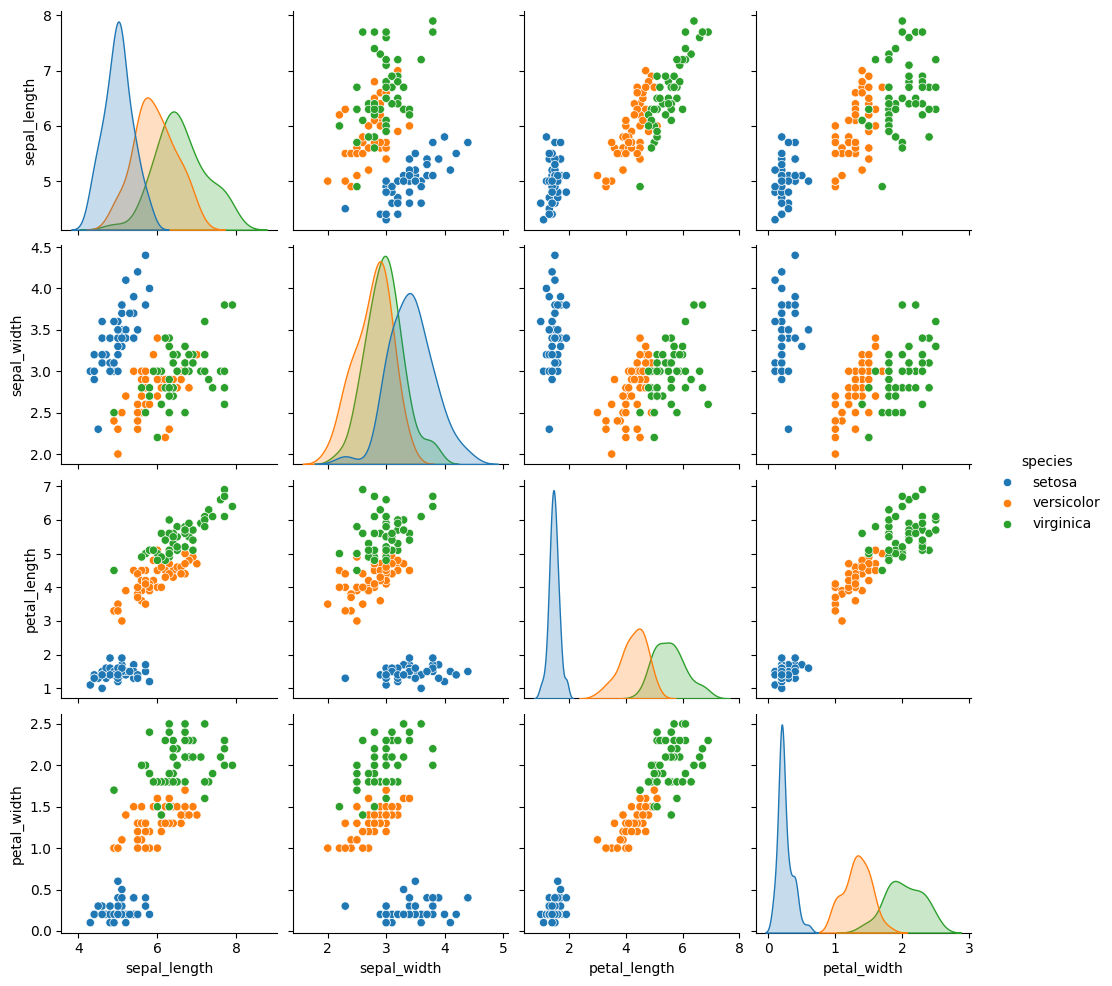

In [12]:
sns.pairplot(data, hue='species')
plt.show()

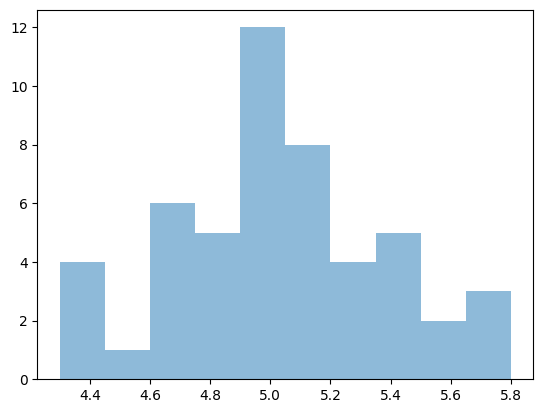

In [13]:
# 1D analysis
import numpy as np
iris_setosa = data.loc[data.species == 'setosa']
iris_versicolor = data.loc[data.species == 'versicolor']
iris_virginica = data.loc[data.species == 'virginica']

# histogram
plt.hist(iris_setosa['sepal_length'], alpha=0.5, label='setosa')
plt.show()

<Axes: xlabel='sepal_length', ylabel='Count'>

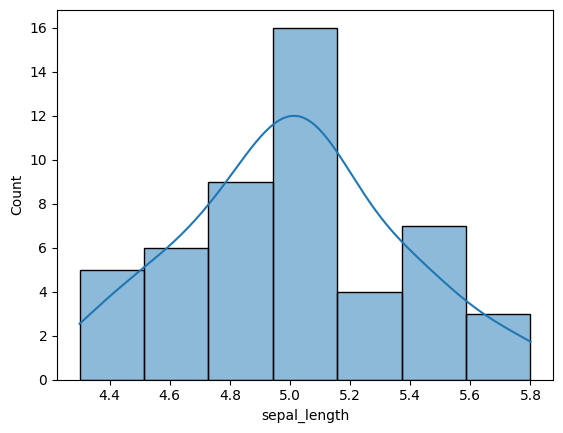

In [14]:
sns.histplot(iris_setosa['sepal_length'], kde=True, label='setosa')

<Axes: xlabel='sepal_length', ylabel='Proportion'>

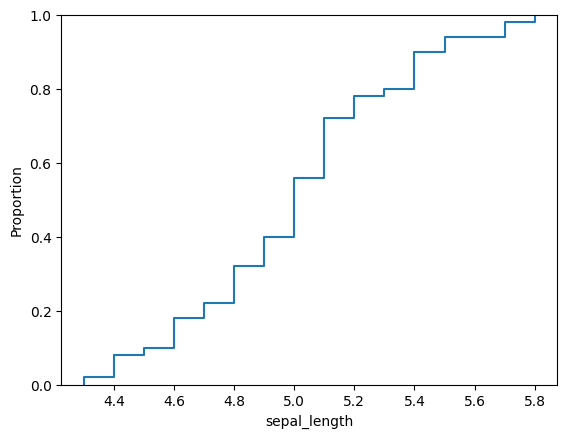

In [15]:
#plot cdf
sns.ecdfplot(iris_setosa['sepal_length'], label='setosa')

0.00    4.3
0.25    5.1
0.50    5.8
0.75    6.4
1.00    7.9
Name: sepal_length, dtype: float64


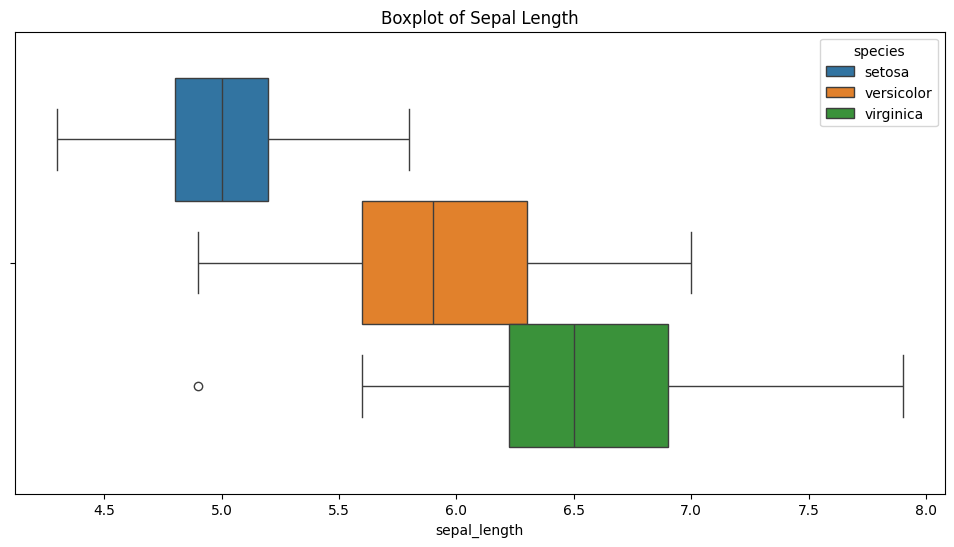

In [19]:
# boxplot 
# lets compute 0th, 25th, 50th, 75th, and 100th percentiles
percentiles = data['sepal_length'].quantile([0, 0.25, 0.5, 0.75, 1])
print(percentiles)

plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='sepal_length',hue='species')
plt.title('Boxplot of Sepal Length')
plt.show()

In [21]:
print(data['sepal_length'].mean())
data['sepal_length'].std()

5.843333333333334


np.float64(0.828066127977863)

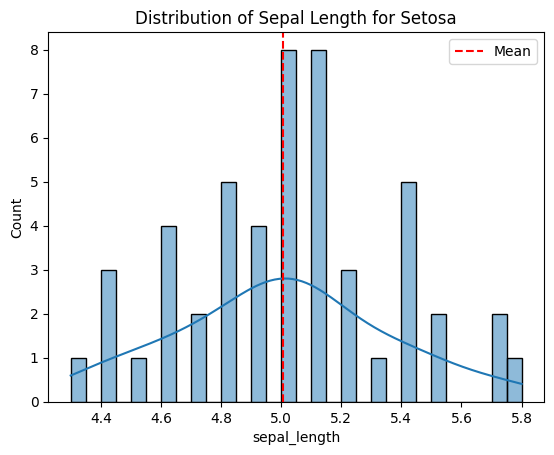

In [28]:
# plot the distribution of sepal length also keep mean
sns.histplot(data=data[data.species == 'setosa'], x='sepal_length', kde=True, bins=30)
plt.axvline(data[data.species == 'setosa']['sepal_length'].mean(), color='r', linestyle='--', label='Mean')
plt.title('Distribution of Sepal Length for Setosa')
plt.legend()
plt.show()

In [25]:
data.shape

(150, 5)

In [26]:
data.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64